# Bacterial Leaching of Sulphide Ores or Uranium Ores


## Bacteria used for leaching is called as **Acidithiobacillus ferrooxidans**

$$\text{UO}_{2}+2\text{Fe}^{3+}\xrightarrow{\text{Chemical}}\text{UO}_{2}^{2+}+2\text{Fe}^{2+}$$

Here U gets oxidized to a soluble form. Also used in Uranium ores to oxidize.

$$MS + 2\text{Fe}^{3+} \xrightarrow{\text{chemical}} M^{2+} + \text{S}^0 + 2\text{Fe}^{2+}$$

Here S gets oxidized, leaving $M^{2+}$ in solution.

$\text{Fe}^{3+}$ attacks the insoluble metal sulfide ore ($MS$, such as chalcopyrite $\text{CuFeS}_2$ or pyrite $\text{FeS}_2$) or Uranium ores, releasing the dissolved metal ion ($\text{M}^{2+}$) into solution while being reduced to ferrous iron ($\text{Fe}^{2+}$):

Acidophilic bacteria attached to the ore surface absorb $\text{Fe}^{2+}$ as their energy source. Using dissolved oxygen, they oxidize these products back into $\text{Fe}^{3+}$
$$\text{Iron oxidation: } 4\text{Fe}^{2+} + 4\text{H}^+ + \text{O}_2 \xrightarrow{\text{bacteria}} 4\text{Fe}^{3+} + 2\text{H}_2\text{O}$$

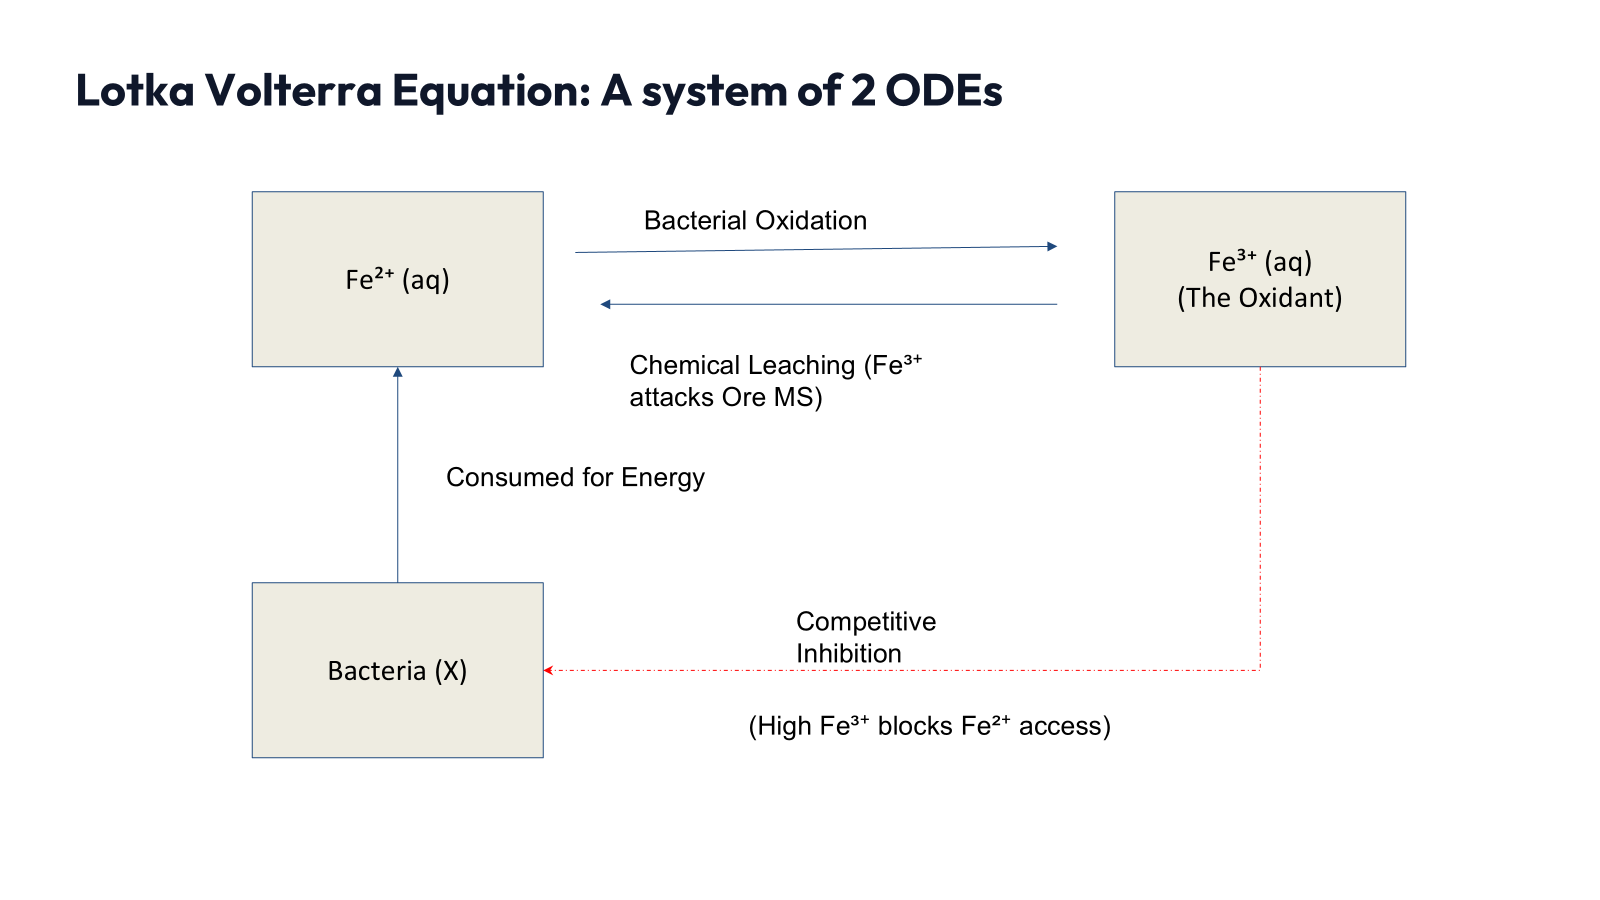

Bacterial Growth Equation (X=bacteria):$$\frac{dX}{dt} = \underbrace{\mu X [{Fe}^{2+}]}_{\text{Growth via consuming } \text{Fe}^{2+}} - \underbrace{k_d X}_{\text{Death}}$$

Reagent Equation ($Y=\text{Fe}^{3+}$) :$$\frac{dY}{dt} = \underbrace{k_1 X [{Fe}^{2+}]}_{\text{Bacterial production of } \text{Fe}^{3+}} - \underbrace{k_2 Y [MS]}_{\text{Consumption of } \text{Fe}^{3+} \text{ by ore}}$$

<!-- $$\frac{dS}{dt} = \underbrace{k_2 Y [MS]}_{\text{Regeneration of } \text{Fe}^{2+} \text{ from ore}} - \underbrace{k_1 X S}_{\text{Depletion of } \text{Fe}^{2+} \text{ by bacteria}}$$ -->

$X$ = Bacterial population density

$Y$ = Ferric iron $[\text{Fe}^{3+}]$ concentration (the leaching agent)

# Lotka-Volterra Predator (Lion) -Prey (Deer) Model

## System Equations
These are two coupled ODEs.
The Lotka-Volterra equations describe the dynamic interaction between two species: a **prey** population ($x$) and a **predator** population ($y$).

$$\frac{dx}{dt} = \alpha x - \beta x y$$

$$\frac{dy}{dt} = -\gamma y + \delta x y$$

The same equations also describe chemical concentration evolution in chemical and material reactions.

### Model Parameters
* $\alpha$: Growth rate of the prey population in the absence of predators.
* $\beta$: Mortality rate of prey per predator-prey interaction (kill rate).
* $\gamma$: Natural death rate of the predator population in the absence of prey.
* $\delta$: Growth rate of the predator population.

### Conserved Quantity
Dividing $\frac{dy}{dt}$ by $\frac{dx}{dt}$ eliminates time $t$:

$$\frac{dy}{dx} = \frac{y(-\gamma + \delta x)}{x(\alpha - \beta y)}$$

Integrating both sides:

$$V(x, y) = \delta x - \gamma \ln(x) + \beta y - \alpha \ln(y) = C$$

The constant $C$ is determined by the initial conditions $(x_0, y_0)$. Because $V(x, y)$ remains constant over time, solution is closed loop periodic.

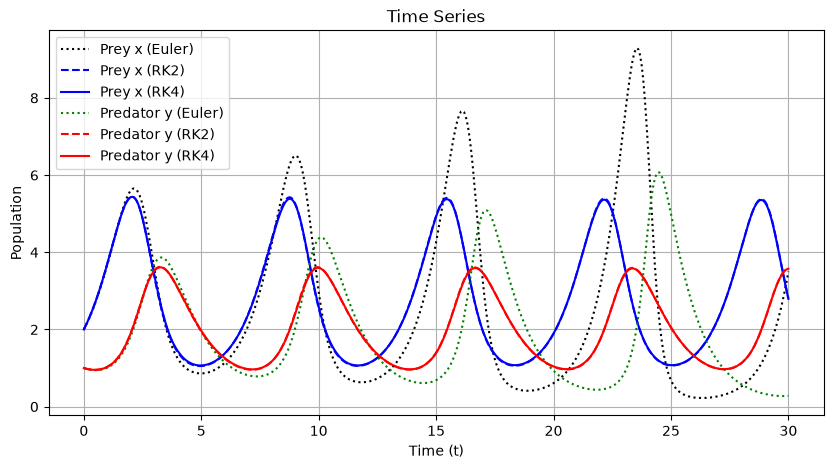

In [5]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Parameters for Case Study 22.6 (Chapra)
alpha = 1.2   # prey growth rate
beta  = 0.6   # predation rate
gamma = 0.8   # predator death rate
delta = 0.3   # predator growth rate

# System of differential equations
def lotka_volterra(t, z):
    x, y = z
    dxdt = alpha * x - beta * x * y
    dydt = -gamma * y + delta * x * y
    return np.array([dxdt, dydt])

# Initial conditions
z0 = [2.0, 1.0]          # Initial populations [x, y]
# z0 = [gamma/delta, alpha/beta]
t_span = (0, 30)         # Time domain
dt = 0.0625*1           # Fixed step size
t_eval = np.arange(t_span[0], t_span[1] + dt, dt)

# Forward Euler Method
num_steps = len(t_eval)
sol_euler = np.zeros((2, num_steps))
sol_euler[:, 0] = z0

for i in range(num_steps - 1):
    dydt = lotka_volterra(t_eval[i], sol_euler[:, i])
    sol_euler[:, i + 1] = sol_euler[:, i] + dt * dydt

# RK23 Method (RK23)
sol_rk2 = solve_ivp(lotka_volterra, t_span, z0, method='RK23', t_eval=t_eval)

# RK4 Method (RK45)
sol_rk4 = solve_ivp(lotka_volterra, t_span, z0, method='RK45', t_eval=t_eval)

# Plotting Results
plt.figure(figsize=(10, 5))

# Time-Series Plot
plt.plot(t_eval, sol_euler[0], 'k:', label='Prey x (Euler)')
plt.plot(sol_rk2.t, sol_rk2.y[0], 'b--', label='Prey x (RK2)')
plt.plot(sol_rk4.t, sol_rk4.y[0], 'b-', label='Prey x (RK4)')

plt.plot(t_eval, sol_euler[1], 'g:', label='Predator y (Euler)')
plt.plot(sol_rk2.t, sol_rk2.y[1], 'r--', label='Predator y (RK2)')
plt.plot(sol_rk4.t, sol_rk4.y[1], 'r-', label='Predator y (RK4)')

plt.xlabel('Time (t)')
plt.ylabel('Population')
plt.title('Time Series')
plt.legend()
plt.grid(True)




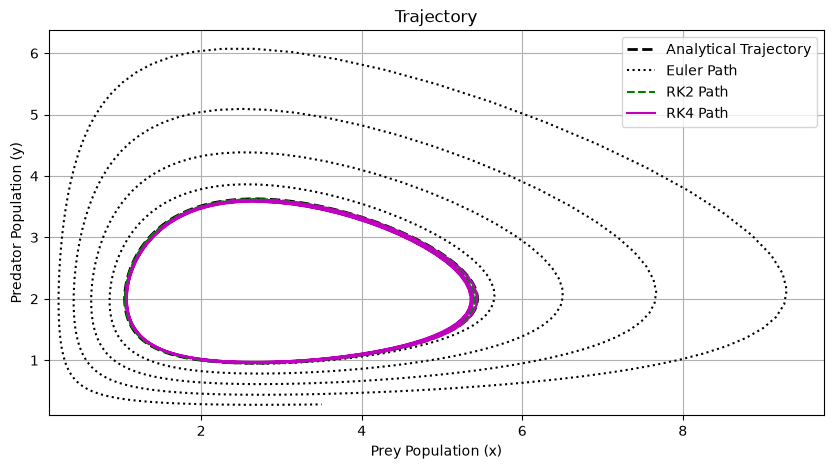

In [7]:
plt.figure(figsize=(10, 5))
# Compute Analytical Curve V(x, y) = C
x_grid = np.linspace(0.1, 7.0, 400)
y_grid = np.linspace(0.1, 5.0, 400)
X, Y = np.meshgrid(x_grid, y_grid)
V = delta * X - gamma * np.log(X) + beta * Y - alpha * np.log(Y)
C_init = delta * z0[0] - gamma * np.log(z0[0]) + beta * z0[1] - alpha * np.log(z0[1])

plt.contour(X, Y, V, levels=[C_init], colors='black', linewidths=2, linestyles='--')
plt.plot([], [], 'k--', linewidth=2, label='Analytical Trajectory')

plt.plot(sol_euler[0], sol_euler[1], 'k:', label='Euler Path')
plt.plot(sol_rk2.y[0], sol_rk2.y[1], 'g--', label='RK2 Path')
plt.plot(sol_rk4.y[0], sol_rk4.y[1], 'm-', label='RK4 Path')

plt.xlabel('Prey Population (x)')
plt.ylabel('Predator Population (y)')
plt.title('Trajectory')
plt.legend()
plt.grid(True)

plt.show()

## Questions: 
Why does the FE, RK2 and RK4 show different loops? Why FE loop expands? Why natural systems usually have negative feedbacks?